In [2]:
import pandas as pd
import numpy as np
from ISLP import load_data, confusion_table
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_validate
from ISLP.models import summarize, ModelSpec as MS
import statsmodels.api as sm
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt



# Question 5

## (a)

In [5]:
Default = load_data('Default')
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [ ]:
x = Default[['income', 'balance']]
x = sm.add_constant(x)
y = (Default['default']=='Yes').astype(int)


In [ ]:
model = sm.GLM(y, x, family=sm.families.Binomial())
results = model.fit()
summarize(results)

,coef,std err,z,P>|z|
const,-11.540500,0.435000,-26.544,0.0
income,0.000021,0.000005,4.174,0.0
balance,0.005600,0.000000,24.835,0.0


## (b)

In [ ]:
default_train, default_validate = train_test_split(Default, train_size=0.7, random_state=1)
x_train = default_train[['income', 'balance']]
x_train = sm.add_constant(x_train)
y_train = (default_train['default']=='Yes').astype(int)
model = sm.GLM(y_train, x_train, family=sm.families.Binomial())
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                default   No. Observations:                 7000
Model:                            GLM   Df Residuals:                     6997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -551.52
Date:                Wed, 22 Apr 2026   Deviance:                       1103.0
Time:                        09:58:43   Pearson chi2:                 4.14e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1333
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.8581      0.528    -22.477      0.000     -12.892     -10.824
income      2.223e-05      6e-06      3.707      0.000    1.05e-05     3.4e-05
balance        0.0059      0.000     21.078      0.000       0.005       0.006
==============================================================================
"""

In [ ]:
x_valid = default_validate[['income', 'balance']]
x_valid = sm.add_constant(x_valid)
y_valid = (default_validate['default'] == 'Yes').astype(int)
y_pred_prob = results.predict(x_valid)
y_pred = (y_pred_prob > 0.5).astype(int)




In [ ]:
confusion_table(y_pred, y_valid)

Truth,0,1
Predicted,,
0,2893,58
1,16,33


In [ ]:
print(f'{(1 - accuracy_score(y_pred, y_valid))*100:.3f} %')

2.467 %


## (c)

In [ ]:
def acc_score(test_):
    default_train, default_validate = train_test_split(Default, test_size=test_, random_state=1)
    x_train = default_train[['income', 'balance']]
    x_train = sm.add_constant(x_train)
    y_train = (default_train['default']=='Yes').astype(int)
    model = sm.GLM(y_train, x_train, family=sm.families.Binomial())
    results = model.fit()
    x_valid = default_validate[['income', 'balance']]
    x_valid = sm.add_constant(x_valid)
    y_valid = (default_validate['default'] == 'Yes').astype(int)
    y_pred_prob = results.predict(x_valid)
    y_pred = (y_pred_prob > 0.5).astype(int)
    return(f'{(1 - accuracy_score(y_pred, y_valid))*100:.3f}%')
    
    

In [ ]:
acc_score(0.5), acc_score(0.4), acc_score(0.3), acc_score(0.2), acc_score(0.1)

('2.500%', '2.525%', '2.467%', '2.700%', '3.000%')

## (d)

In [ ]:
default_train, default_validate = train_test_split(Default, test_size=0.3, random_state=1)
default_train['student'] = np.where(default_train['student'] == 'Yes', 1,0)
default_validate['student'] = np.where(default_validate['student'] == 'Yes', 1,0)
x_train = default_train[['income', 'balance', 'student']]
x_train = sm.add_constant(x_train)
y_train = (default_train['default']=='Yes').astype(int)
model = sm.GLM(y_train, x_train, family=sm.families.Binomial())
results = model.fit()
x_valid = default_validate[['income', 'balance', 'student']]
x_valid = sm.add_constant(x_valid)
y_valid = (default_validate['default'] == 'Yes').astype(int)
y_pred_prob = results.predict(x_valid)
y_pred = (y_pred_prob > 0.5).astype(int)
print(f'{(1 - accuracy_score(y_pred, y_valid))*100:.3f}%')

2.433%


using islp lib we can do as following:

In [ ]:
design = MS(['income', 'balance', 'student'])
x = design.fit_transform(Default)
y = Default['default'] == 'Yes'
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.3, random_state=1)
model = sm.GLM(y_train, x_train, family=sm.families.Binomial())
results = model.fit()
pred_proba = results.predict(x_valid)
y_pred = np.where(pred_proba>0.5, 1, 0)
1- accuracy_score(y_pred, y_valid)



0.024333333333333318

# Question 6

## (a)

In [21]:
design = MS(['income', 'balance'])
x = design.fit_transform(Default)
y = Default['default'] == 'Yes'
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)
model = sm.GLM(y_train, x_train, family=sm.families.Binomial())
results = model.fit()
summarize(results)
results.bse



intercept    0.527555
income       0.000006
balance      0.000278
dtype: float64

## (b)

In [18]:
def boot_fn(df: pd.DataFrame, idx: np.ndarray):
    design = MS(['income', 'balance'])
    data = df.loc[idx]
    x = design.fit_transform(data)
    y = data['default'] == 'Yes'
    
    model = sm.GLM(y, x, family=sm.families.Binomial())
    results = model.fit()
    return results.params.loc[['income', 'balance']]
    

In [10]:
rng = np.random.default_rng(0)
boot_fn(Default, rng.choice(len(Default), 100, replace=True))

income     0.000037
balance    0.005290
dtype: float64

## (c)

In [19]:
def boot_se(func,
            df,
            n=None,
            B=1000,
            seed=0):
    rng = np.random.default_rng(seed)
    first_, second_ = 0, 0
    n = n or df.shape[0]
    for _ in range(B):
        idx = rng.choice(len(df), n, replace=True)
        value = func(df, idx)
        first_ += value
        second_ += value**2
    return np.sqrt(second_/B - (first_/B)**2)
    
    
    

In [20]:
SE_params = boot_se(boot_fn, Default, B=1000, seed=0)
SE_params

income     0.000005
balance    0.000230
dtype: float64

## (d)

In [22]:
print(results.bse.loc[['income', 'balance']])
print(SE_params)

income     0.000006
balance    0.000278
dtype: float64
income     0.000005
balance    0.000230
dtype: float64


## Question 7

In [3]:
weekly = load_data('Weekly')
weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


## (a)

In [4]:
design = MS(['Lag1', 'Lag2'])
x = design.fit_transform(weekly)
y = weekly['Direction'] == 'Up'
model = sm.GLM(y, x, family=sm.families.Binomial())
results = model.fit()
summarize(results)


,coef,std err,z,P>|z|
intercept,0.2212,0.061,3.599,0.000
Lag1,-0.0387,0.026,-1.477,0.140
Lag2,0.0602,0.027,2.270,0.023


## (b)

In [5]:
design = MS(['Lag1', 'Lag2'])
x = design.fit_transform(weekly)
y = weekly['Direction'] == 'Up'
x_train = x[1:]
y_train = y[1:]
model = sm.GLM(y_train, x_train, family=sm.families.Binomial())
results = model.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2232,0.061,3.630,0.000
Lag1,-0.0384,0.026,-1.466,0.143
Lag2,0.0608,0.027,2.291,0.022


## (c)

In [6]:
results.predict(x.iloc[0:1])

0    0.571392
dtype: float64

In [7]:
(weekly['Direction']).iloc[0]

'Down'

it predicted up while it was down in dataset

## (d)

In [ ]:
err = np.zeros(weekly.shape[0])
weekly.shape[0]
for i in range(1, weekly.shape[0]):
    #(i)
    design = MS(['Lag1', 'Lag2'])
    x = design.fit_transform(weekly)
    y = weekly['Direction'] == 'Up'
    x_train = x.iloc[x.index != i]
    y_train = y.iloc[y.index != i]
    x_valid = x.iloc[i]
    y_valid = 'Up' if y.iloc[i] else 'Down'
    model = sm.GLM(y_train, x_train, family=sm.families.Binomial())
    results = model.fit()
    
    #(ii)
    y_proba = results.predict(x_valid)
    
    #(iii)
    pred = np.where(y_proba > 0.5, 'Up', 'Down')
    
    #(iv)
    if pred != y_valid:
        err[i] = 1
    else:
        err[i] = 0
      
    

    

In [13]:
np.unique(err, return_counts=True)

(array([0., 1.]), array([600, 489]))

## (e)

In [14]:
err.mean()

np.float64(0.4490358126721763)

# Question 8

## (a)

In [52]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

n = 100 and p = 2 which are x and x²

$ y = x - 2x^2 + € $

## (b)

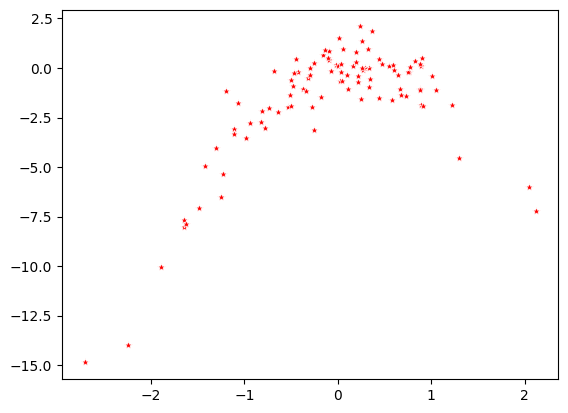

In [25]:
sns.scatterplot(x=x, y=y, color='red', marker='*')
plt.show()

## (c)

In [60]:
x = x.reshape(-1,1)
seed = 1
cv = KFold(n_splits=x.shape[0], random_state=seed, shuffle=True)
err = []
for i in range(1,5):
    model = make_pipeline(PolynomialFeatures(degree=i, include_bias=False), LinearRegression())
    cv_results = cross_validate(model, x, y, cv=cv, scoring='neg_mean_squared_error')
    er1 = -np.mean(cv_results['test_score'])
    err.append(er1)
err
    

[np.float64(6.633029839181984),
 np.float64(1.1229368563419673),
 np.float64(1.3017965489358867),
 np.float64(1.3323942694179294)]

These are the LOOCV error rates for linear, quadratic, cubic and quartic models respectively.

## (d)

now repeating the above calculations using `seed=10`

In [63]:
seed = 10
cv = KFold(n_splits=x.shape[0], random_state=seed, shuffle=True)
err = []
for i in range(1,5):
    model = make_pipeline(PolynomialFeatures(degree=i, include_bias=False), LinearRegression())
    cv_results = cross_validate(model, x, y, cv=cv, scoring='neg_mean_squared_error')
    er1 = -np.mean(cv_results['test_score'])
    err.append(er1)
err

[np.float64(6.633029839181981),
 np.float64(1.1229368563419673),
 np.float64(1.3017965489358867),
 np.float64(1.33239426941793)]

we got same result because LOOCV treats all the  points in the data set equally where it uses each as a test point in one itertaion.

## (e)

The `Quadratic` model has the least LOOCV error. It was expected because the original equation $Y = X - 2X^2 + ɛ$ is quadratic one and when plotting the scatter plot, we had observed that the trend was similar to quadratic.

## (f)

In [66]:

for i in range(1,5):
    poly = PolynomialFeatures(degree=i, include_bias=False)
    x_poly = poly.fit_transform(x)
    x_poly = sm.add_constant(x_poly)
    model = sm.OLS(y, x_poly).fit()
    print(summarize(model))

         coef  std err      t  P>|t|
const -1.4650    0.247 -5.937    0.0
x1     1.9494    0.289  6.752    0.0
         coef  std err       t  P>|t|
const -0.0728    0.119  -0.611  0.543
x1     0.9663    0.126   7.647  0.000
x2    -2.0047    0.091 -22.072  0.000
         coef  std err       t  P>|t|
const -0.0572    0.120  -0.477  0.635
x1     1.1146    0.187   5.945  0.000
x2    -2.0471    0.099 -20.673  0.000
x3    -0.0643    0.060  -1.070  0.287
         coef  std err       t  P>|t|
const  0.1008    0.136   0.743  0.460
x1     0.9050    0.205   4.423  0.000
x2    -2.5059    0.221 -11.336  0.000
x3     0.0338    0.073   0.466  0.642
x4     0.1042    0.045   2.309  0.023


From these results too we can see that quadratic and linear are only significant based on p-values

# Question 9

## (a)

In [3]:
boston = load_data('Boston')
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [4]:
μ = np.mean(boston['medv'])
μ

np.float64(22.532806324110677)

## (b)

In [5]:
se = np.std(boston['medv'])/ np.sqrt(boston.shape[0])
se


np.float64(0.4084569346972866)

## (c)

In [6]:
def mean(df, idx):
    return np.mean(df.iloc[idx])

def se_mean(func, D, n=None, B=1000, seed=0):
    rng = np.random.default_rng(seed)
    first_, second_ = 0, 0
    n = n or D.shape[0]
    for _ in range(B):
        idx = rng.choice(D.index, n, replace=True)
        value = func(D, idx)
        first_ += value
        second_ += value**2
    return np.sqrt(second_ / B - (first_ / B)**2)
    
    

In [8]:
se_boot = se_mean(mean, boston['medv'], B=10000, seed=1)
se_boot

np.float64(0.40976659164537216)

The value came out to be quite similar to the one we had obtained in b.

## (d)

In [9]:
lower = μ - 2*se_boot
upper = μ + 2*se_boot
lower, upper

(np.float64(21.713273140819933), np.float64(23.35233950740142))

## (e)

In [10]:
med = np.median(boston['medv'])
med

np.float64(21.2)

## (f)

In [15]:
def med_(df, idx):
    return np.median(df.iloc[idx])

def med_bootstrap(func, D, n=None, B=10000, seed=0):
    rng = np.random.default_rng(seed)
    first_, second_ = 0, 0
    n = n or D.shape[0]
    for _ in range(B):
        idx = rng.choice(D.index, n, replace=True)
        value = func(D, idx)
        first_ += value
        second_ += value**2
    return np.sqrt(second_ / B - (first_ / B)**2)

In [17]:
med_bootstrap(med_, boston['medv'], B=10000, seed=1)

np.float64(0.37954976997614637)

## (g)

In [19]:
mu_01 = np.percentile(boston['medv'], 10)
mu_01

np.float64(12.75)

## (h)

In [22]:
def mu_01_(df, idx):
    return np.percentile(df.iloc[idx], 10)

we can use the same fucntion to calc this too

In [24]:
se_mu = med_bootstrap(mu_01_, boston['medv'], B=10000, seed=0)
se_mu

np.float64(0.5035641412764847)